# Task 1: Particle Field Evolution (x_t -> Delta x_t)

This notebook is **Task-1 only** and follows the corrected temporal-learning setup:
- model input: particle state at time `t`
- model target: state increment `Delta state_t = state_{t+1} - state_t`
- rollout: autoregressive (`x_hat[t+1] = x_hat[t] + Delta_hat[t]`)
- split: by case (not by nearby frames)


In [1]:
from pathlib import Path
import json
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

NOTEBOOK_VERSION = 'task1_evolution_v1_2026-05-09'
print('Notebook version:', NOTEBOOK_VERSION)

# Resolve final-2 base robustly
CWD = Path.cwd().resolve()
if (CWD / 'final-2' / 'output').exists():
    BASE = CWD / 'final-2'
elif (CWD.name == 'notebooks') and (CWD.parent / 'output').exists():
    BASE = CWD.parent
else:
    BASE = CWD

DATA_PATH = BASE / 'output' / 'particle_evolution_dataset.npz'
OUT_DIR = BASE / 'output' / 'task1_evolution_training'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Base:', BASE)
print('DATA_PATH:', DATA_PATH)
print('Exists?:', DATA_PATH.exists())
print('Device:', DEVICE)
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing dataset: {DATA_PATH} (run preprocess_data.py)')


Notebook version: task1_evolution_v1_2026-05-09
Base: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2
DATA_PATH: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\particle_evolution_dataset.npz
Exists?: True
Device: cuda


In [2]:
# ----------------------------
# Load dataset + print shapes
# ----------------------------
ds = np.load(DATA_PATH, allow_pickle=True)

X = ds['inputs_t_norm'].astype(np.float32)
Y = ds['targets_delta_norm'].astype(np.float32)
X_raw = ds['inputs_t'].astype(np.float32)
Y_raw = ds['targets_delta'].astype(np.float32)

feature_names = [str(x) for x in ds['feature_names'].tolist()]
state_names = [str(x) for x in ds['state_names'].tolist()]
target_names = [str(x) for x in ds['target_names'].tolist()]

pair_ranges = list(ds['pair_ranges'])
pair_contexts = list(ds['pair_contexts'])

train_pair_ids = ds['train_pair_ids'].astype(np.int64)
val_pair_ids = ds['val_pair_ids'].astype(np.int64)
test_pair_ids = ds['test_pair_ids'].astype(np.int64)

train_rows = ds['train_rows'].astype(np.int64)
val_rows = ds['val_rows'].astype(np.int64)
test_rows = ds['test_rows'].astype(np.int64)

rollout_cases = [str(x) for x in ds['rollout_cases'].tolist()]
rollout_true_states = list(ds['rollout_true_states'])   # object list, each [T,N,7]
rollout_phases = list(ds['rollout_phases'])             # object list, each [T]
rollout_dts = ds['rollout_dts'].astype(np.float32)

train_cases = [str(x) for x in ds['train_cases'].tolist()]
val_cases = [str(x) for x in ds['val_cases'].tolist()]
test_cases = [str(x) for x in ds['test_cases'].tolist()]

in_mean = ds['in_mean'].astype(np.float32)
in_std = ds['in_std'].astype(np.float32)
out_mean = ds['out_mean'].astype(np.float32)
out_std = ds['out_std'].astype(np.float32)

print('inputs_t_norm shape      :', X.shape)
print('targets_delta_norm shape :', Y.shape)
print('inputs_t raw shape       :', X_raw.shape)
print('targets_delta raw shape  :', Y_raw.shape)
print('n_pairs                  :', len(pair_ranges))
print('n_rollout_cases          :', len(rollout_cases))
print('feature_names            :', feature_names)
print('state_names              :', state_names)
print('target_names             :', target_names)
print('train/val/test pairs     :', len(train_pair_ids), len(val_pair_ids), len(test_pair_ids))
print('train/val/test rows      :', len(train_rows), len(val_rows), len(test_rows))
print('train/val/test cases     :', train_cases, val_cases, test_cases)


inputs_t_norm shape      : (16501285, 7)
targets_delta_norm shape : (16501285, 7)
inputs_t raw shape       : (16501285, 7)
targets_delta raw shape  : (16501285, 7)
n_pairs                  : 996
n_rollout_cases          : 5
feature_names            : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma']
state_names              : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma']
target_names             : ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma']
train/val/test pairs     : 598 199 199
train/val/test rows      : 9486157 2514015 4501113
train/val/test cases     : ['1', '2', '7'] ['8'] ['9']


In [3]:
# ------------------------------------------------------
# Dataset class: one sample = one temporal pair (variable N)
# ------------------------------------------------------
class PairDataset(Dataset):
    def __init__(self, X, Y, pair_ranges, pair_ids):
        self.X = X
        self.Y = Y
        self.pair_ranges = pair_ranges
        self.pair_ids = [int(i) for i in pair_ids]

    def __len__(self):
        return len(self.pair_ids)

    def __getitem__(self, idx):
        pid = self.pair_ids[idx]
        case, fr_t, fr_tp1, s, e, n = self.pair_ranges[pid]
        s, e = int(s), int(e)
        x = torch.from_numpy(self.X[s:e])
        y = torch.from_numpy(self.Y[s:e])
        meta = {
            'pair_id': pid,
            'case': str(case),
            'fr_t': str(fr_t),
            'fr_tp1': str(fr_tp1),
            'n': int(n),
        }
        return x, y, meta


def collate_pair(batch):
    xs, ys, ms = zip(*batch)
    return list(xs), list(ys), list(ms)

train_ds = PairDataset(X, Y, pair_ranges, train_pair_ids)
val_ds = PairDataset(X, Y, pair_ranges, val_pair_ids)
test_ds = PairDataset(X, Y, pair_ranges, test_pair_ids)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_pair)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_pair)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_pair)

print('pair datasets:', len(train_ds), len(val_ds), len(test_ds))


pair datasets: 598 199 199


largest pair: pair_id=398, case=2, 000199->000200, n=42860


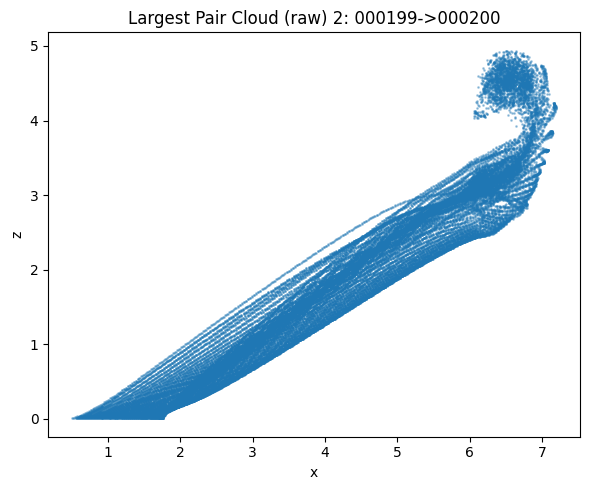

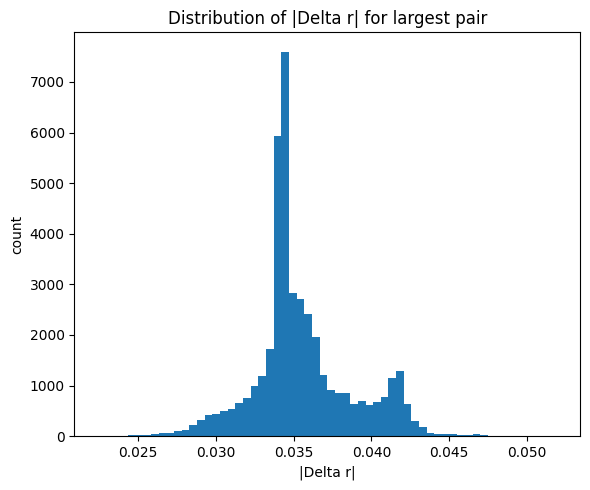

In [4]:
# -----------------------------------------
# Quick data sanity plots (meaningful cases)
# -----------------------------------------
# Plot largest pair cloud in raw coordinates
pair_sizes = np.array([int(r[5]) for r in pair_ranges], dtype=np.int64)
max_pid = int(np.argmax(pair_sizes))
case, fr_t, fr_tp1, s, e, n = pair_ranges[max_pid]
s, e = int(s), int(e)

# x,y,z are first 3 channels in X_raw by design
xyz = X_raw[s:e, 0:3]
dxyz = Y_raw[s:e, 0:3]

print(f'largest pair: pair_id={max_pid}, case={case}, {fr_t}->{fr_tp1}, n={n}')

plt.figure(figsize=(6,5))
plt.scatter(xyz[:,0], xyz[:,2], s=1, alpha=0.35)
plt.title(f'Largest Pair Cloud (raw) {case}: {fr_t}->{fr_tp1}')
plt.xlabel('x'); plt.ylabel('z'); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.hist(np.linalg.norm(dxyz, axis=1), bins=60)
plt.title('Distribution of |Delta r| for largest pair')
plt.xlabel('|Delta r|'); plt.ylabel('count'); plt.tight_layout(); plt.show()


In [5]:
# --------------------------
# Build Task-1 evolution GNO
# --------------------------
import inspect

try:
    from neuralop.layers.gno_block import GNOBlock
except Exception as exc:
    raise RuntimeError('Need neuralop with GNOBlock for Task-1 notebook') from exc


def rel_l2(pred, tgt, eps=1e-12):
    d = (pred - tgt).reshape(pred.shape[0], -1)
    t = tgt.reshape(tgt.shape[0], -1)
    return (torch.linalg.norm(d, dim=1) / torch.linalg.norm(t, dim=1).clamp_min(eps)).mean()


class ParticleEvolutionGNO(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=96, n_layers=3, radius=0.12):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
        )

        sig = inspect.signature(GNOBlock.__init__)
        p = sig.parameters
        extra = {}
        if 'use_torch_scatter_reduce' in p:
            extra['use_torch_scatter_reduce'] = False
        if 'use_open3d_neighbor_search' in p:
            extra['use_open3d_neighbor_search'] = False

        self.blocks = nn.ModuleList([
            GNOBlock(
                in_channels=hidden,
                out_channels=hidden,
                coord_dim=3,
                radius=radius,
                transform_type='linear',
                reduction='mean',
                pos_embedding_type='transformer',
                pos_embedding_channels=12,
                channel_mlp_layers=[hidden, hidden, hidden],
                **extra,
            )
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        # First three features are x,y,z by construction.
        pos = x[:, :3]
        h = self.enc(x)
        for blk, norm in zip(self.blocks, self.norms):
            u = blk(y=pos, x=pos, f_y=h)
            if u.ndim == 3 and u.shape[0] == 1:
                u = u.squeeze(0)
            h = norm(h + u)
        return self.head(h)


model = ParticleEvolutionGNO(
    in_dim=X.shape[1],
    out_dim=Y.shape[1],
    hidden=96,
    n_layers=3,
    radius=0.12,
).to(DEVICE)

print('model params:', sum(p.numel() for p in model.parameters() if p.requires_grad))


model params: 118279


In [6]:
# ------------------
# Optimizer + config
# ------------------
opt_cls = None
try:
    import neuralop.training as nt
    opt_cls = getattr(nt, 'AdamW', None) or getattr(nt, 'Adam', None)
except Exception:
    pass
if opt_cls is None:
    opt_cls = torch.optim.AdamW

optimizer = opt_cls(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

EPOCHS = 80
MAX_NODES = 1024
PAIRS_PER_EPOCH = 96
VAL_PAIRS_LIMIT = 48
ROLLOUT_PARTICLE_LIMIT = 2048
PRINT_EVERY_STEPS = 8

print('Training config:', {
    'EPOCHS': EPOCHS,
    'MAX_NODES': MAX_NODES,
    'PAIRS_PER_EPOCH': PAIRS_PER_EPOCH,
    'VAL_PAIRS_LIMIT': VAL_PAIRS_LIMIT,
    'ROLLOUT_PARTICLE_LIMIT': ROLLOUT_PARTICLE_LIMIT,
})


Training config: {'EPOCHS': 80, 'MAX_NODES': 1024, 'PAIRS_PER_EPOCH': 96, 'VAL_PAIRS_LIMIT': 48, 'ROLLOUT_PARTICLE_LIMIT': 2048}


In [7]:
# -------------------------------------------------------------
# Rollout logic + metrics (autoregressive, no future gt inputs)
# -------------------------------------------------------------
feature_index = {k: i for i, k in enumerate(feature_names)}
state_index = {k: i for i, k in enumerate(state_names)}

def denorm_delta(delta_norm):
    return delta_norm * out_std + out_mean

def norm_features(x):
    return (x - in_mean) / in_std


def make_input_from_state(state_t, phase_t, aoa, fs):
    # state_t shape: [N,7] in order STATE_NAMES
    N = state_t.shape[0]
    feat = np.zeros((N, len(feature_names)), dtype=np.float32)

    feat[:, feature_index['x']] = state_t[:, state_index['x']]
    feat[:, feature_index['y']] = state_t[:, state_index['y']]
    feat[:, feature_index['z']] = state_t[:, state_index['z']]
    feat[:, feature_index['Gamma_x']] = state_t[:, state_index['Gamma_x']]
    feat[:, feature_index['Gamma_y']] = state_t[:, state_index['Gamma_y']]
    feat[:, feature_index['Gamma_z']] = state_t[:, state_index['Gamma_z']]
    feat[:, feature_index['sigma']] = state_t[:, state_index['sigma']]

    # Optional context channels: assign only if present in feature set.
    if 'phase' in feature_index:
        feat[:, feature_index['phase']] = phase_t
    if 'angle_of_attack' in feature_index:
        feat[:, feature_index['angle_of_attack']] = aoa
    if 'freestream_x' in feature_index:
        feat[:, feature_index['freestream_x']] = fs[0]
    if 'freestream_y' in feature_index:
        feat[:, feature_index['freestream_y']] = fs[1]
    if 'freestream_z' in feature_index:
        feat[:, feature_index['freestream_z']] = fs[2]
    return feat


def rel_feature_err(pred, true, eps=1e-12):
    num = np.linalg.norm(pred - true)
    den = np.linalg.norm(true) + eps
    return float(num / den)


def rollout_case(case_name, true_states, phase_seq, dt, aoa, fs, particle_limit=2048):
    # true_states: [T, N, 7]
    T, N, F = true_states.shape
    useN = min(N, particle_limit)

    true = true_states[:, :useN, :].astype(np.float32)
    pred = np.zeros_like(true)
    pred[0] = true[0]

    for t in range(T - 1):
        x_feat = make_input_from_state(pred[t], float(phase_seq[t]), float(aoa), fs.astype(np.float32))
        x_norm = norm_features(x_feat).astype(np.float32)

        with torch.no_grad():
            xt = torch.from_numpy(x_norm).to(DEVICE)
            d_norm = model(xt).cpu().numpy()
        d = denorm_delta(d_norm).astype(np.float32)

        pred[t + 1] = pred[t] + d

    # Metrics across timesteps
    pos_err = []
    gamma_err = []
    sigma_err = []
    mse_state = []
    drift = []
    per_feature = {name: [] for name in state_names}

    for t in range(T):
        tp = pred[t]
        tt = true[t]
        pos_err.append(rel_feature_err(tp[:, 0:3], tt[:, 0:3]))
        gamma_err.append(rel_feature_err(tp[:, 3:6], tt[:, 3:6]))
        sigma_err.append(rel_feature_err(tp[:, 6:7], tt[:, 6:7]))

        mse_state.append(float(np.mean((tp - tt) ** 2)))
        drift.append(float(np.mean(np.linalg.norm(tp[:, 0:3] - tt[:, 0:3], axis=1))))

        for j, name in enumerate(state_names):
            per_feature[name].append(rel_feature_err(tp[:, j:j+1], tt[:, j:j+1]))

    return {
        'case': case_name,
        'true': true,
        'pred': pred,
        'pos_err_t': np.asarray(pos_err, dtype=np.float32),
        'gamma_err_t': np.asarray(gamma_err, dtype=np.float32),
        'sigma_err_t': np.asarray(sigma_err, dtype=np.float32),
        'mse_state_t': np.asarray(mse_state, dtype=np.float32),
        'drift_t': np.asarray(drift, dtype=np.float32),
        'per_feature_t': {k: np.asarray(v, dtype=np.float32) for k, v in per_feature.items()},
    }


# Build case metadata lookup from saved dict
case_meta_raw = ds['case_metadata'].reshape(-1)[0]
if isinstance(case_meta_raw, np.ndarray):
    case_meta_raw = case_meta_raw.item()
if hasattr(case_meta_raw, 'item') and not isinstance(case_meta_raw, dict):
    case_meta_raw = case_meta_raw.item()
CASE_META = case_meta_raw if isinstance(case_meta_raw, dict) else {}


def eval_pair_loader(loader, max_pairs=64):
    model.eval()
    rels = []
    mses = []
    with torch.no_grad():
        for b, (xs, ys, ms) in enumerate(loader):
            if b >= max_pairs:
                break
            x, y = xs[0], ys[0]
            if x.shape[0] > MAX_NODES:
                idx = torch.randperm(x.shape[0])[:MAX_NODES]
                x, y = x[idx], y[idx]
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model(x)
            rels.append(float(rel_l2(p.unsqueeze(0), y.unsqueeze(0)).item()))
            mses.append(float(torch.mean((p - y) ** 2).item()))
    return float(np.mean(rels)), float(np.mean(mses))


def eval_rollout_cases(case_list):
    model.eval()
    results = []
    for cname in case_list:
        if cname not in rollout_cases:
            continue
        ci = rollout_cases.index(cname)
        true_states = np.asarray(rollout_true_states[ci], dtype=np.float32)
        phase_seq = np.asarray(rollout_phases[ci], dtype=np.float32)
        dt = float(rollout_dts[ci])

        meta = CASE_META.get(cname, {}) if isinstance(CASE_META, dict) else {}

        aoa_raw = meta.get('aoa_deg', 0.0)
        aoa = 0.0 if aoa_raw is None else float(aoa_raw)

        fs_raw = meta.get('freestream', [0.0, 0.0, 0.0])
        if fs_raw is None:
            fs = np.asarray([0.0, 0.0, 0.0], dtype=np.float32)
        else:
            fs = np.asarray(fs_raw, dtype=np.float32).reshape(-1)
            if fs.shape[0] != 3:
                fs = np.asarray([0.0, 0.0, 0.0], dtype=np.float32)

        res = rollout_case(cname, true_states, phase_seq, dt, aoa, fs, particle_limit=ROLLOUT_PARTICLE_LIMIT)
        results.append(res)

    # aggregate summary
    if not results:
        return None, []

    agg = {
        'pos_err_last': float(np.mean([r['pos_err_t'][-1] for r in results])),
        'gamma_err_last': float(np.mean([r['gamma_err_t'][-1] for r in results])),
        'sigma_err_last': float(np.mean([r['sigma_err_t'][-1] for r in results])),
        'mse_state_last': float(np.mean([r['mse_state_t'][-1] for r in results])),
        'drift_last': float(np.mean([r['drift_t'][-1] for r in results])),
    }
    return agg, results


In [8]:
# -----------------------------
# Training loop + checkpointing
# -----------------------------
history = []
best_val = np.inf
best_state = None
best_rollout = None

# Smoke test to catch hangs early
print('Running smoke test...')
x0, y0, m0 = train_ds[0]
if x0.shape[0] > MAX_NODES:
    idx = torch.randperm(x0.shape[0])[:MAX_NODES]
    x0, y0 = x0[idx], y0[idx]

_t0 = time.time()
x0t, y0t = x0.to(DEVICE), y0.to(DEVICE)
p0 = model(x0t)
loss0 = rel_l2(p0.unsqueeze(0), y0t.unsqueeze(0))
loss0.backward()
optimizer.zero_grad(set_to_none=True)
print(f'Smoke OK | n={x0.shape[0]} | sec={time.time()-_t0:.2f}')

for ep in range(1, EPOCHS + 1):
    t_ep = time.time()
    model.train()
    losses = []

    use_pairs = min(PAIRS_PER_EPOCH, len(train_ds))
    picks = np.random.choice(len(train_ds), size=use_pairs, replace=False)

    for step, ridx in enumerate(picks, start=1):
        x, y, meta = train_ds[int(ridx)]
        if x.shape[0] > MAX_NODES:
            idx = torch.randperm(x.shape[0])[:MAX_NODES]
            x, y = x[idx], y[idx]

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        p = model(x)
        loss = rel_l2(p.unsqueeze(0), y.unsqueeze(0))
        loss.backward()
        optimizer.step()

        losses.append(float(loss.item()))
        if step % PRINT_EVERY_STEPS == 0:
            print(f'[ep {ep:03d}] step {step:03d}/{use_pairs} train_rel={loss.item():.6f}', flush=True)

    scheduler.step()

    tr_loss = float(np.mean(losses))
    val_rel, val_mse = eval_pair_loader(val_loader, max_pairs=VAL_PAIRS_LIMIT)
    test_rel, test_mse = eval_pair_loader(test_loader, max_pairs=VAL_PAIRS_LIMIT)

    rollout_val_summary, _ = eval_rollout_cases(val_cases)

    row = {
        'epoch': ep,
        'train_rel_l2': tr_loss,
        'val_rel_l2': val_rel,
        'val_mse': val_mse,
        'test_rel_l2': test_rel,
        'test_mse': test_mse,
        'epoch_sec': float(time.time() - t_ep),
    }
    if rollout_val_summary is not None:
        row.update({f'rollout_{k}': float(v) for k, v in rollout_val_summary.items()})

    history.append(row)

    # checkpoint criterion: pair-level val rel_l2
    if val_rel < best_val:
        best_val = val_rel
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        best_rollout = rollout_val_summary

    # Print rich metrics every epoch
    msg = (
        f"[epoch {ep:03d}] train={tr_loss:.6f} val={val_rel:.6f} test={test_rel:.6f} "
        f"sec={row['epoch_sec']:.1f}"
    )
    if rollout_val_summary is not None:
        msg += (
            f" | roll_pos_last={rollout_val_summary['pos_err_last']:.5f}"
            f" roll_gamma_last={rollout_val_summary['gamma_err_last']:.5f}"
            f" roll_sigma_last={rollout_val_summary['sigma_err_last']:.5f}"
        )
    print(msg, flush=True)

    # Save running history every epoch
    (OUT_DIR / 'history.json').write_text(json.dumps(history, indent=2))

# Load best checkpoint
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), OUT_DIR / 'best_particle_evolution_gno.pt')
summary = {
    'best_val_rel_l2': float(best_val),
    'best_rollout': best_rollout,
    'epochs': EPOCHS,
    'device': str(DEVICE),
    'train_pairs': len(train_ds),
    'val_pairs': len(val_ds),
    'test_pairs': len(test_ds),
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
print('Saved summary:', json.dumps(summary, indent=2))


Running smoke test...
Smoke OK | n=1 | sec=0.19
[ep 001] step 008/96 train_rel=0.965460
[ep 001] step 016/96 train_rel=0.897565
[ep 001] step 024/96 train_rel=0.836492
[ep 001] step 032/96 train_rel=0.913443
[ep 001] step 040/96 train_rel=0.810265
[ep 001] step 048/96 train_rel=0.864775
[ep 001] step 056/96 train_rel=0.749893
[ep 001] step 064/96 train_rel=0.837935
[ep 001] step 072/96 train_rel=0.967867
[ep 001] step 080/96 train_rel=0.974335
[ep 001] step 088/96 train_rel=0.917439
[ep 001] step 096/96 train_rel=0.969101
[epoch 001] train=0.882530 val=0.529122 test=0.978256 sec=151.9 | roll_pos_last=0.58608 roll_gamma_last=2.02551 roll_sigma_last=1.04066
[ep 002] step 008/96 train_rel=0.754075
[ep 002] step 016/96 train_rel=0.806534
[ep 002] step 024/96 train_rel=0.945119
[ep 002] step 032/96 train_rel=0.959015
[ep 002] step 040/96 train_rel=0.871194
[ep 002] step 048/96 train_rel=0.909861
[ep 002] step 056/96 train_rel=0.806913
[ep 002] step 064/96 train_rel=0.699491
[ep 002] step 07

In [15]:
# ---------------------------------------------------
# Final rollout evaluation + save predictions/errors
# ---------------------------------------------------
val_roll_summary, val_roll_results = eval_rollout_cases(val_cases)
test_roll_summary, test_roll_results = eval_rollout_cases(test_cases)

print('VAL rollout summary:', val_roll_summary)
print('TEST rollout summary:', test_roll_summary)

# Save rollout arrays (object container to preserve variable shapes)
np.savez_compressed(
    OUT_DIR / 'rollout_predictions.npz',
    val_results=np.asarray(val_roll_results, dtype=object),
    test_results=np.asarray(test_roll_results, dtype=object),
)

(OUT_DIR / 'rollout_summary.json').write_text(
    json.dumps({'val': val_roll_summary, 'test': test_roll_summary}, indent=2)
)

# Save compact numeric arrays for quick post-processing
if test_roll_results:
    pos_curves = np.asarray([r['pos_err_t'] for r in test_roll_results], dtype=object)
    gamma_curves = np.asarray([r['gamma_err_t'] for r in test_roll_results], dtype=object)
    sigma_curves = np.asarray([r['sigma_err_t'] for r in test_roll_results], dtype=object)
    np.savez_compressed(
        OUT_DIR / 'rollout_error_arrays.npz',
        pos_err_curves=pos_curves,
        gamma_err_curves=gamma_curves,
        sigma_err_curves=sigma_curves,
    )


VAL rollout summary: {'pos_err_last': 0.6306549906730652, 'gamma_err_last': 8.282894134521484, 'sigma_err_last': 0.9311792850494385, 'mse_state_last': 4.1517014503479, 'drift_last': 5.3903913497924805}
TEST rollout summary: {'pos_err_last': 0.2876001000404358, 'gamma_err_last': 1.3628989458084106, 'sigma_err_last': 0.606654942035675, 'mse_state_last': 0.7061294317245483, 'drift_last': 2.222060203552246}


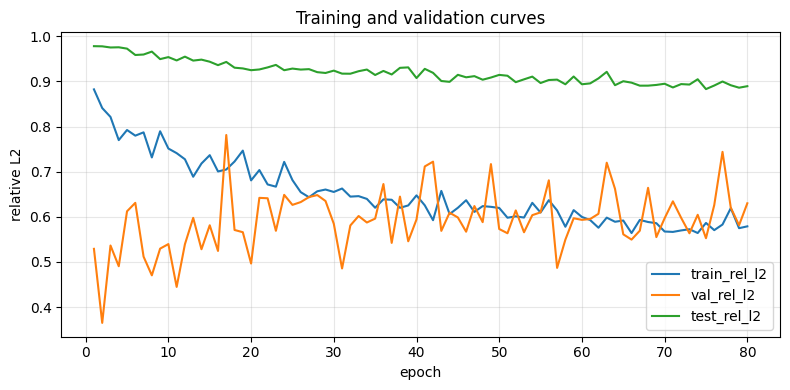

Visualization case=9 | T=200 | N=1
Note: rollout arrays contain only one particle (N=1); using single-particle-safe plots.


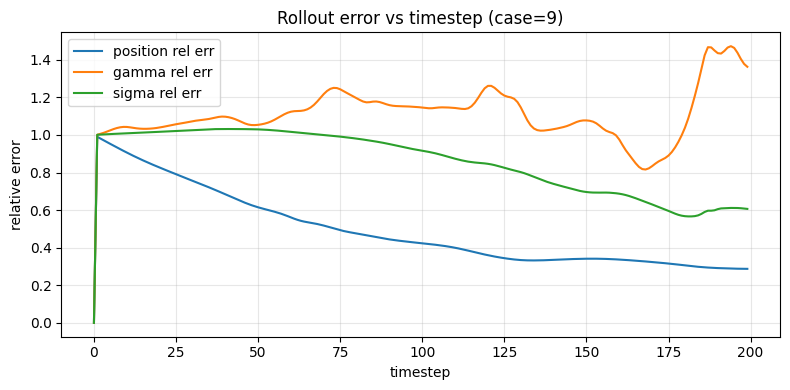

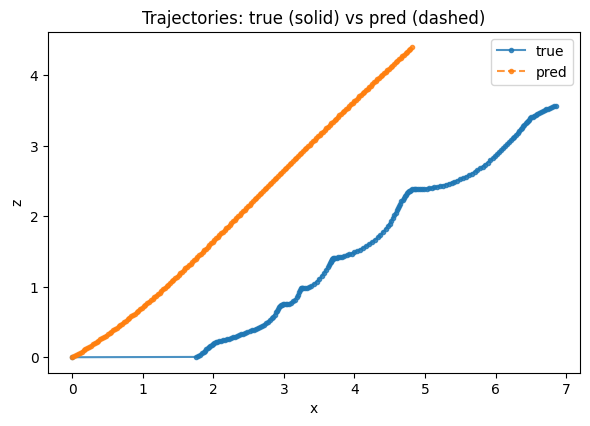

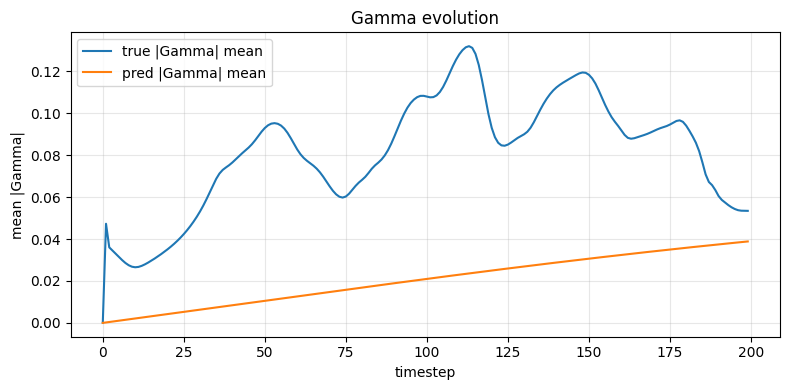

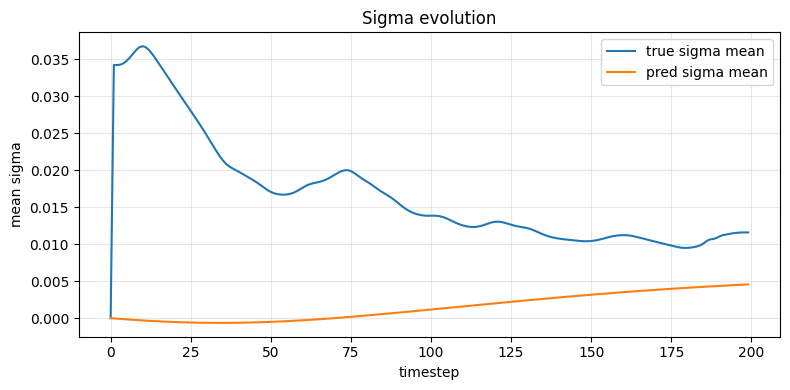

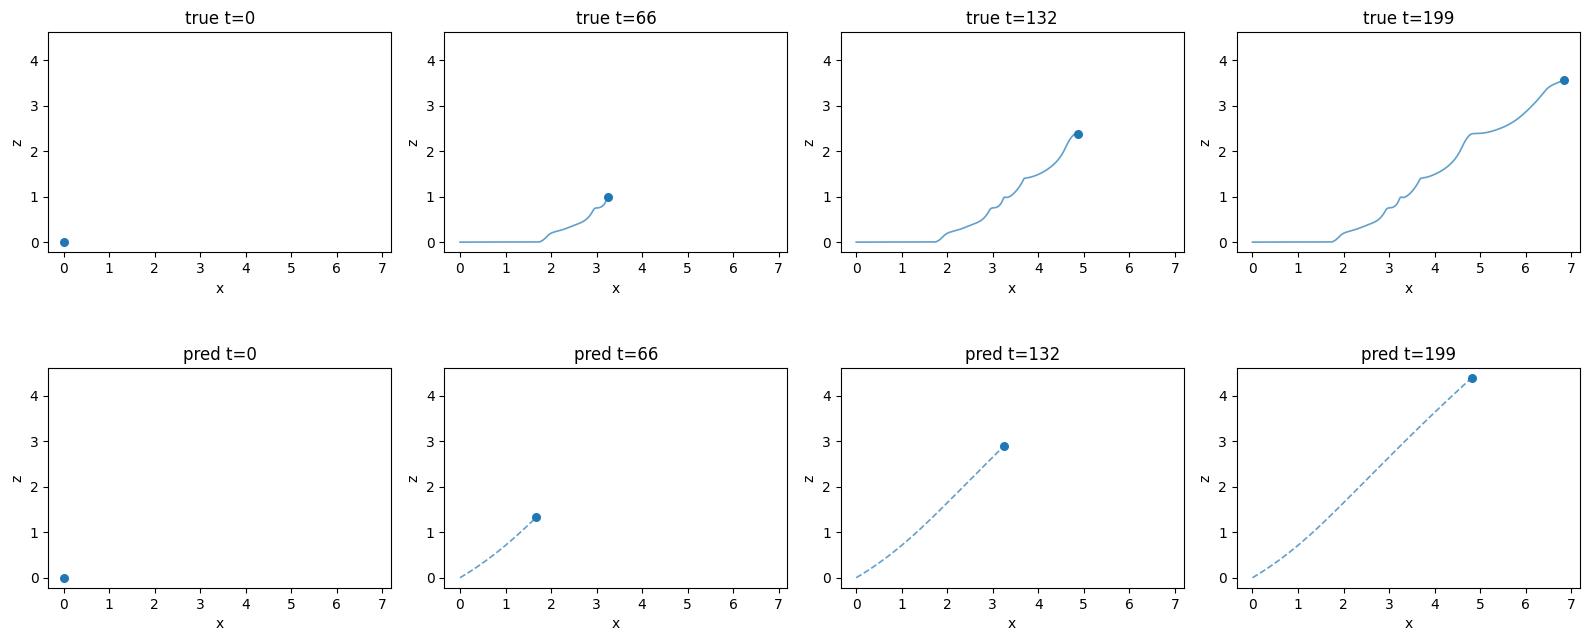

Saved rollout frame sequence to C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_evolution_training\rollout_frames


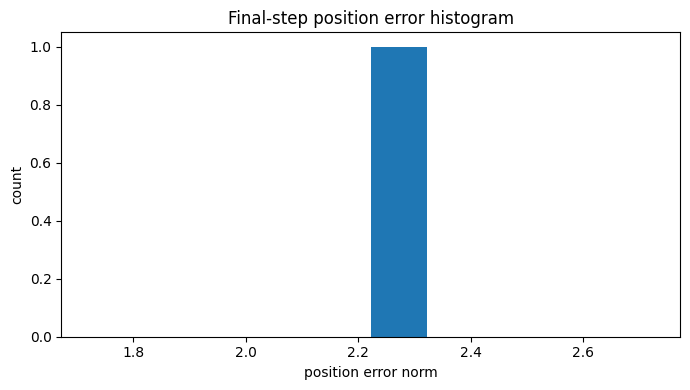

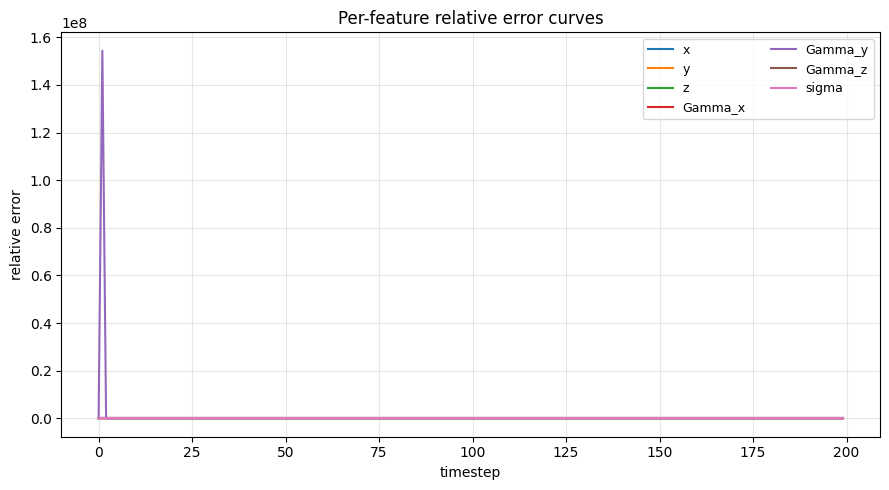

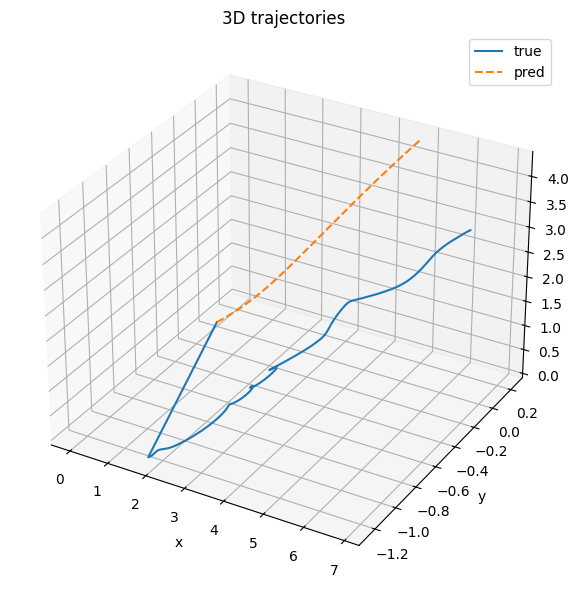

In [16]:
# -------------------------
# Visualization pack (10x)
# -------------------------
# 1) training + validation losses
plt.figure(figsize=(8,4))
plt.plot([h['epoch'] for h in history], [h['train_rel_l2'] for h in history], label='train_rel_l2')
plt.plot([h['epoch'] for h in history], [h['val_rel_l2'] for h in history], label='val_rel_l2')
plt.plot([h['epoch'] for h in history], [h['test_rel_l2'] for h in history], label='test_rel_l2')
plt.grid(alpha=0.3); plt.legend(); plt.xlabel('epoch'); plt.ylabel('relative L2')
plt.title('Training and validation curves')
plt.tight_layout(); plt.show()

# pick one rollout result for detailed plots
pick = test_roll_results[0] if test_roll_results else (val_roll_results[0] if val_roll_results else None)
if pick is None:
    raise RuntimeError('No rollout results available for plotting')

true = pick['true']
pred = pick['pred']
pos_err_t = pick['pos_err_t']
gamma_err_t = pick['gamma_err_t']
sigma_err_t = pick['sigma_err_t']
per_feature_t = pick['per_feature_t']

T, N, _ = true.shape
t = np.arange(T)
print(f'Visualization case={pick["case"]} | T={T} | N={N}')
if N <= 1:
    print('Note: rollout arrays contain only one particle (N=1); using single-particle-safe plots.')

# Global limits to avoid misleading autoscale between subplots.
x_all = np.concatenate([true[:, :, 0].reshape(-1), pred[:, :, 0].reshape(-1)])
z_all = np.concatenate([true[:, :, 2].reshape(-1), pred[:, :, 2].reshape(-1)])
x_pad = max(1e-3, 0.05 * max(1e-6, float(x_all.max() - x_all.min())))
z_pad = max(1e-3, 0.05 * max(1e-6, float(z_all.max() - z_all.min())))
x_lim = (float(x_all.min() - x_pad), float(x_all.max() + x_pad))
z_lim = (float(z_all.min() - z_pad), float(z_all.max() + z_pad))

# 2) rollout error vs timestep
plt.figure(figsize=(8,4))
plt.plot(t, pos_err_t, label='position rel err')
plt.plot(t, gamma_err_t, label='gamma rel err')
plt.plot(t, sigma_err_t, label='sigma rel err')
plt.xlabel('timestep'); plt.ylabel('relative error'); plt.grid(alpha=0.3); plt.legend()
plt.title(f'Rollout error vs timestep (case={pick["case"]})')
plt.tight_layout(); plt.show()

# 3) predicted vs true particle trajectories
sample_ids = np.array([0], dtype=int) if N <= 1 else np.linspace(0, N-1, num=min(8, N), dtype=int)
plt.figure(figsize=(6,5))
if N <= 1:
    plt.plot(true[:, 0, 0], true[:, 0, 2], '-o', ms=3, alpha=0.8, label='true')
    plt.plot(pred[:, 0, 0], pred[:, 0, 2], '--o', ms=3, alpha=0.8, label='pred')
else:
    for pid in sample_ids:
        plt.plot(true[:, pid, 0], true[:, pid, 2], '-', alpha=0.6)
        plt.plot(pred[:, pid, 0], pred[:, pid, 2], '--', alpha=0.6)
plt.xlim(*x_lim); plt.ylim(*z_lim)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x'); plt.ylabel('z'); plt.title('Trajectories: true (solid) vs pred (dashed)')
if N <= 1:
    plt.legend()
plt.tight_layout(); plt.show()

# 4) Gamma evolution (mean norm)
g_true = np.linalg.norm(true[:, :, 3:6], axis=2).mean(axis=1)
g_pred = np.linalg.norm(pred[:, :, 3:6], axis=2).mean(axis=1)
plt.figure(figsize=(8,4))
plt.plot(t, g_true, label='true |Gamma| mean')
plt.plot(t, g_pred, label='pred |Gamma| mean')
plt.xlabel('timestep'); plt.ylabel('mean |Gamma|'); plt.grid(alpha=0.3); plt.legend()
plt.title('Gamma evolution')
plt.tight_layout(); plt.show()

# 5) sigma evolution (mean)
s_true = true[:, :, 6].mean(axis=1)
s_pred = pred[:, :, 6].mean(axis=1)
plt.figure(figsize=(8,4))
plt.plot(t, s_true, label='true sigma mean')
plt.plot(t, s_pred, label='pred sigma mean')
plt.xlabel('timestep'); plt.ylabel('mean sigma'); plt.grid(alpha=0.3); plt.legend()
plt.title('Sigma evolution')
plt.tight_layout(); plt.show()

# 6) spatial cloud comparison at multiple timesteps
snap_ids = np.linspace(0, T-1, num=min(4, T), dtype=int)
fig, axs = plt.subplots(2, len(snap_ids), figsize=(4*len(snap_ids), 7))
if len(snap_ids) == 1:
    axs = np.asarray(axs).reshape(2, 1)

for j, k in enumerate(snap_ids):
    if N <= 1:
        axs[0, j].plot(true[:k+1, 0, 0], true[:k+1, 0, 2], '-', lw=1.2, alpha=0.7)
        axs[0, j].scatter(true[k, 0, 0], true[k, 0, 2], s=30)
        axs[1, j].plot(pred[:k+1, 0, 0], pred[:k+1, 0, 2], '--', lw=1.2, alpha=0.7)
        axs[1, j].scatter(pred[k, 0, 0], pred[k, 0, 2], s=30)
    else:
        axs[0, j].scatter(true[k,:,0], true[k,:,2], s=1, alpha=0.8)
        axs[1, j].scatter(pred[k,:,0], pred[k,:,2], s=1, alpha=0.8)
    axs[0, j].set_title(f'true t={k}')
    axs[1, j].set_title(f'pred t={k}')

for a in axs.ravel():
    a.set_xlabel('x'); a.set_ylabel('z')
    a.set_xlim(*x_lim); a.set_ylim(*z_lim)
    a.set_aspect('equal', adjustable='box')
fig.tight_layout(); plt.show()

# 7) simple autoregressive rollout visualization frames -> saved PNG sequence
roll_dir = OUT_DIR / 'rollout_frames'
roll_dir.mkdir(parents=True, exist_ok=True)
for k in range(T):
    plt.figure(figsize=(6,5))
    if N <= 1:
        plt.plot(true[:k+1,0,0], true[:k+1,0,2], '-', alpha=0.8, label='true traj')
        plt.plot(pred[:k+1,0,0], pred[:k+1,0,2], '--', alpha=0.8, label='pred traj')
        plt.scatter(true[k,0,0], true[k,0,2], s=25, alpha=0.9)
        plt.scatter(pred[k,0,0], pred[k,0,2], s=25, alpha=0.9)
    else:
        plt.scatter(true[k,:,0], true[k,:,2], s=1, alpha=0.5, label='true')
        plt.scatter(pred[k,:,0], pred[k,:,2], s=1, alpha=0.5, label='pred')
    plt.title(f'Rollout frame t={k}')
    plt.xlabel('x'); plt.ylabel('z')
    plt.xlim(*x_lim); plt.ylim(*z_lim)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(); plt.tight_layout()
    plt.savefig(roll_dir / f'frame_{k:04d}.png', dpi=120)
    plt.close()
print('Saved rollout frame sequence to', roll_dir)

# 8) histogram of prediction errors at final timestep
err_final = np.linalg.norm(pred[-1,:,0:3] - true[-1,:,0:3], axis=1)
plt.figure(figsize=(7,4))
plt.hist(err_final, bins=min(60, max(10, len(err_final))))
plt.xlabel('position error norm'); plt.ylabel('count'); plt.title('Final-step position error histogram')
plt.tight_layout(); plt.show()

# 9) per-feature normalized error curves
plt.figure(figsize=(9,5))
for name in state_names:
    plt.plot(t, per_feature_t[name], label=name)
plt.xlabel('timestep'); plt.ylabel('relative error'); plt.grid(alpha=0.3)
plt.title('Per-feature relative error curves')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

# 10) 3D trajectory visualization over time (sampled particles)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
if N <= 1:
    ax.plot(true[:, 0, 0], true[:, 0, 1], true[:, 0, 2], '-', label='true')
    ax.plot(pred[:, 0, 0], pred[:, 0, 1], pred[:, 0, 2], '--', label='pred')
    ax.legend()
else:
    for pid in sample_ids:
        ax.plot(true[:, pid, 0], true[:, pid, 1], true[:, pid, 2], alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('3D trajectories')
plt.tight_layout(); plt.show()



case=9: N=1 in rollout arrays, plotting time-series instead of spatial fields.


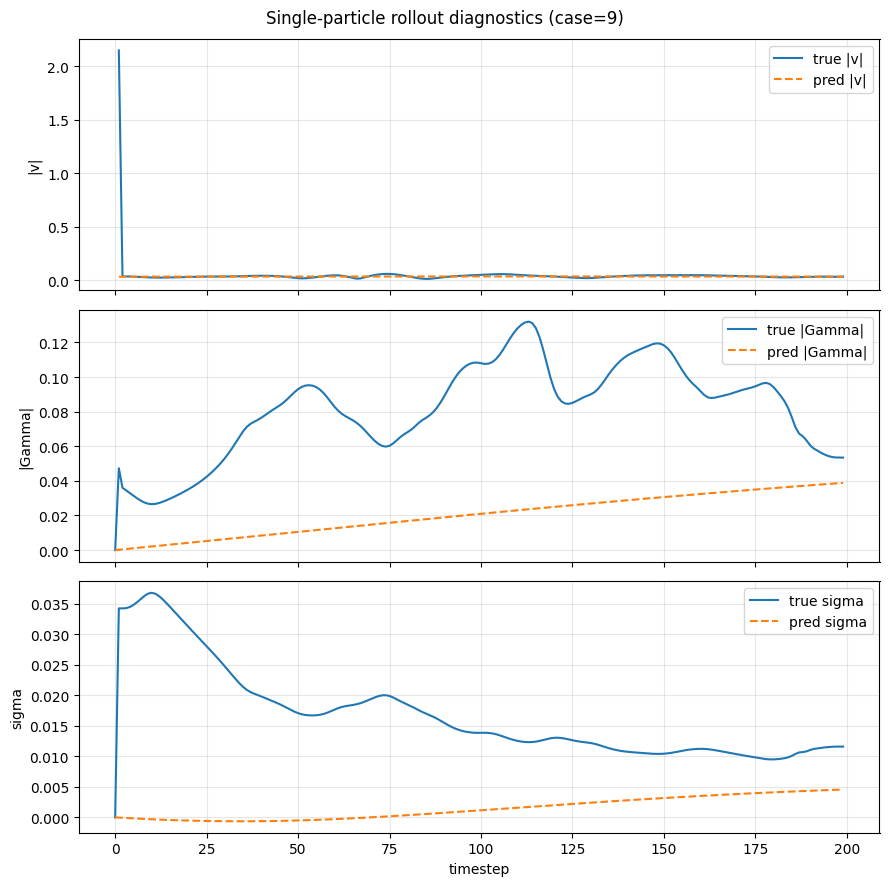

In [17]:
# -------------------------------------------------------------
# Extra: test-case particle field snapshots at chosen timestep t
# Quantities: velocity (derived), |Gamma|, sigma
# -------------------------------------------------------------

if not test_roll_results:
    print('No test rollout results available for snapshot plotting.')
else:
    snap = test_roll_results[0]
    true = snap['true']     # [T, N, 7]
    pred = snap['pred']     # [T, N, 7]
    case_name = snap['case']

    T, N, _ = true.shape

    # dt for this case (fallback=1.0)
    if case_name in rollout_cases:
        ci = rollout_cases.index(case_name)
        dt = float(rollout_dts[ci]) if float(rollout_dts[ci]) != 0.0 else 1.0
    else:
        dt = 1.0

    if N <= 1:
        print(f'case={case_name}: N=1 in rollout arrays, plotting time-series instead of spatial fields.')
        t = np.arange(T)
        v_true = np.linalg.norm((true[1:] - true[:-1])[:, 0, 0:3] / dt, axis=1)
        v_pred = np.linalg.norm((pred[1:] - pred[:-1])[:, 0, 0:3] / dt, axis=1)
        g_true = np.linalg.norm(true[:, 0, 3:6], axis=1)
        g_pred = np.linalg.norm(pred[:, 0, 3:6], axis=1)
        s_true = true[:, 0, 6]
        s_pred = pred[:, 0, 6]

        fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
        axs[0].plot(t[1:], v_true, label='true |v|')
        axs[0].plot(t[1:], v_pred, '--', label='pred |v|')
        axs[0].set_ylabel('|v|'); axs[0].grid(alpha=0.3); axs[0].legend()

        axs[1].plot(t, g_true, label='true |Gamma|')
        axs[1].plot(t, g_pred, '--', label='pred |Gamma|')
        axs[1].set_ylabel('|Gamma|'); axs[1].grid(alpha=0.3); axs[1].legend()

        axs[2].plot(t, s_true, label='true sigma')
        axs[2].plot(t, s_pred, '--', label='pred sigma')
        axs[2].set_xlabel('timestep'); axs[2].set_ylabel('sigma')
        axs[2].grid(alpha=0.3); axs[2].legend()

        fig.suptitle(f'Single-particle rollout diagnostics (case={case_name})')
        fig.tight_layout()
        plt.show()

    else:
        t_plot = min(max(1, T // 2), T - 1)   # pick a valid interior timestep

        # Plane for plotting: x-z (same as previous sample plot)
        x_true = true[t_plot, :, 0]
        z_true = true[t_plot, :, 2]
        x_pred = pred[t_plot, :, 0]
        z_pred = pred[t_plot, :, 2]

        # 1) Velocity magnitude at time t (derived from state increments)
        v_true = np.linalg.norm((true[t_plot] - true[t_plot - 1])[:, 0:3] / dt, axis=1)
        v_pred = np.linalg.norm((pred[t_plot] - pred[t_plot - 1])[:, 0:3] / dt, axis=1)

        # 2) Gamma magnitude at time t
        g_true = np.linalg.norm(true[t_plot, :, 3:6], axis=1)
        g_pred = np.linalg.norm(pred[t_plot, :, 3:6], axis=1)

        # 3) Sigma at time t
        s_true = true[t_plot, :, 6]
        s_pred = pred[t_plot, :, 6]

        print(f'Plotting case={case_name}, timestep={t_plot}/{T-1}, n_particles={N}, dt={dt}')

        def _plot_pair(x1, z1, q1, x2, z2, q2, title, cbar):
            fig, axs = plt.subplots(1, 2, figsize=(12, 5))
            vmin = float(min(np.min(q1), np.min(q2)))
            vmax = float(max(np.max(q1), np.max(q2)))

            sc1 = axs[0].scatter(x1, z1, c=q1, s=2, cmap='turbo', vmin=vmin, vmax=vmax)
            axs[0].set_title('True')
            axs[0].set_xlabel('x'); axs[0].set_ylabel('z')
            axs[0].set_aspect('equal', adjustable='box')
            fig.colorbar(sc1, ax=axs[0], label=cbar)

            sc2 = axs[1].scatter(x2, z2, c=q2, s=2, cmap='turbo', vmin=vmin, vmax=vmax)
            axs[1].set_title('Pred')
            axs[1].set_xlabel('x'); axs[1].set_ylabel('z')
            axs[1].set_aspect('equal', adjustable='box')
            fig.colorbar(sc2, ax=axs[1], label=cbar)

            fig.suptitle(title)
            fig.tight_layout()
            plt.show()

        _plot_pair(x_true, z_true, v_true, x_pred, z_pred, v_pred,
                   f'Particle Velocity Magnitude at t={t_plot} (derived)', '|v|')

        _plot_pair(x_true, z_true, g_true, x_pred, z_pred, g_pred,
                   f'Particle Gamma Magnitude at t={t_plot}', '|Gamma|')

        _plot_pair(x_true, z_true, s_true, x_pred, z_pred, s_pred,
                   f'Particle Sigma at t={t_plot}', 'sigma')



test pair case=9 frame_t=000198 frame_tp1=000199 orig_n=42831 plotted_n=12000 pair_rel_l2=0.259988


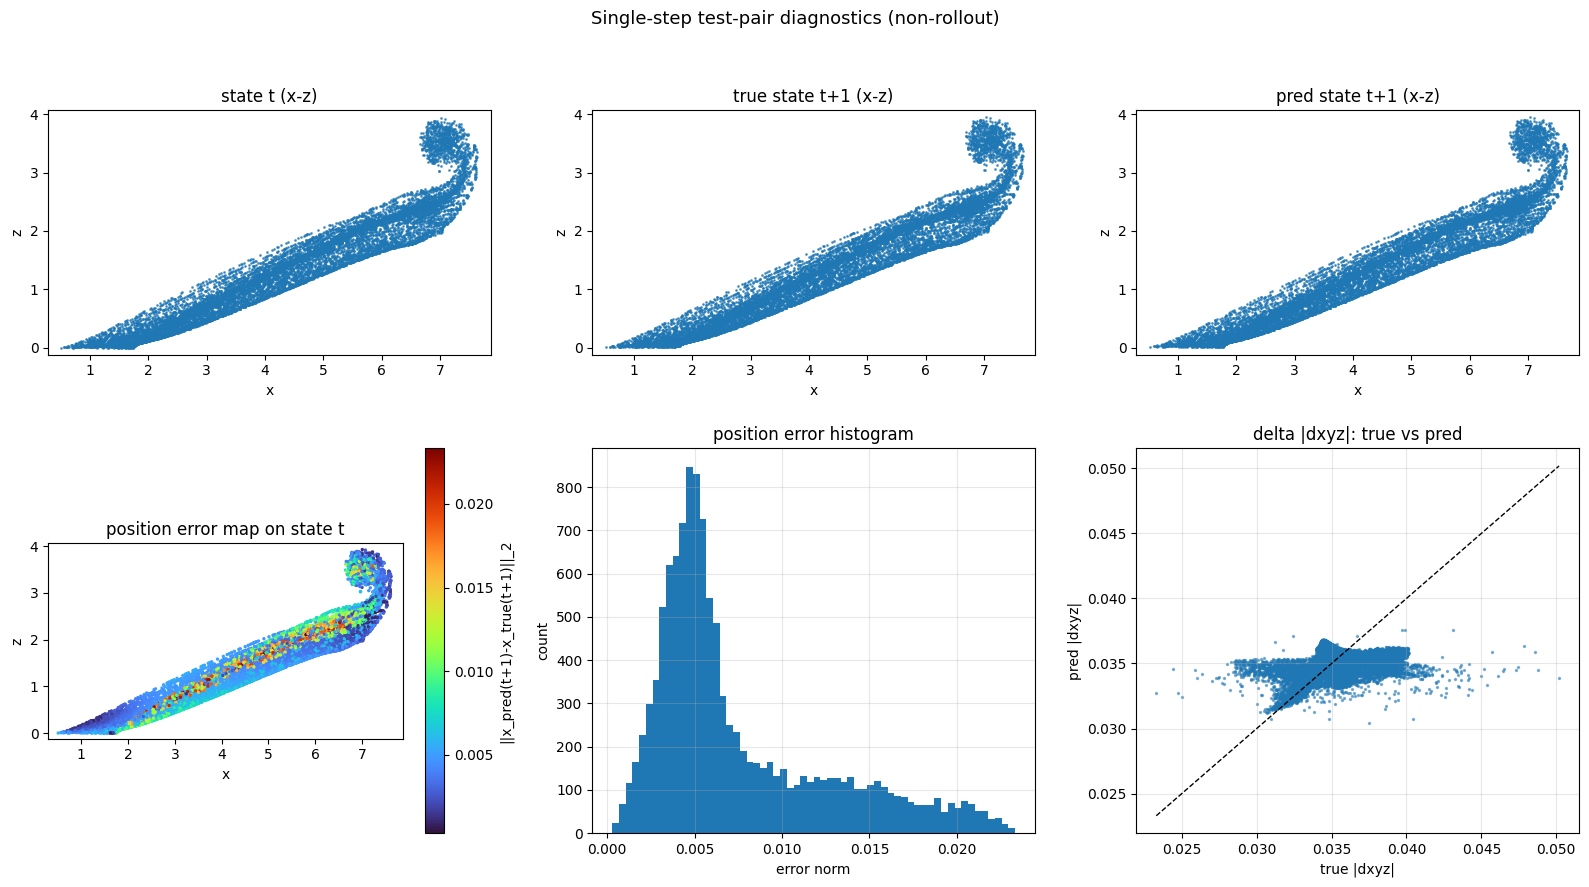

In [18]:
# -------------------------------------------------------------
# Normal test-pair plot (single-step, non-rollout)
# -------------------------------------------------------------
if len(test_pair_ids) == 0:
    print('No test pairs available.')
else:
    # Pick the densest test pair so we visualize a full cloud.
    test_pids = [int(i) for i in test_pair_ids]
    best_pid = max(test_pids, key=lambda pid: int(pair_ranges[pid][5]))
    case, fr_t, fr_tp1, s, e, n = pair_ranges[best_pid]
    s, e, n = int(s), int(e), int(n)

    x_norm = X[s:e].astype(np.float32)
    y_norm = Y[s:e].astype(np.float32)

    # Keep plotting lightweight while preserving cloud structure.
    PLOT_MAX_PARTICLES = 12000
    if n > PLOT_MAX_PARTICLES:
        rng = np.random.default_rng(0)
        pick = rng.choice(n, size=PLOT_MAX_PARTICLES, replace=False)
        x_norm = x_norm[pick]
        y_norm = y_norm[pick]

    x_t = (x_norm * in_std + in_mean).astype(np.float32)
    d_true = (y_norm * out_std + out_mean).astype(np.float32)

    model.eval()
    with torch.no_grad():
        xt = torch.from_numpy(x_norm).to(DEVICE)
        d_pred_norm = model(xt).cpu().numpy().astype(np.float32)
    d_pred = (d_pred_norm * out_std + out_mean).astype(np.float32)

    nxt_true = x_t + d_true
    nxt_pred = x_t + d_pred

    # Relative L2 on this test pair subset.
    pair_rel = np.linalg.norm(d_pred - d_true) / (np.linalg.norm(d_true) + 1e-12)
    pos_err = np.linalg.norm(nxt_pred[:, 0:3] - nxt_true[:, 0:3], axis=1)

    print(
        f'test pair case={case} frame_t={fr_t} frame_tp1={fr_tp1} '
        f'orig_n={n} plotted_n={x_t.shape[0]} pair_rel_l2={pair_rel:.6f}'
    )

    # Shared limits for fair visual comparison.
    x_all = np.concatenate([x_t[:, 0], nxt_true[:, 0], nxt_pred[:, 0]])
    z_all = np.concatenate([x_t[:, 2], nxt_true[:, 2], nxt_pred[:, 2]])
    x_pad = max(1e-3, 0.03 * max(1e-6, float(x_all.max() - x_all.min())))
    z_pad = max(1e-3, 0.03 * max(1e-6, float(z_all.max() - z_all.min())))
    x_lim = (float(x_all.min() - x_pad), float(x_all.max() + x_pad))
    z_lim = (float(z_all.min() - z_pad), float(z_all.max() + z_pad))

    fig, axs = plt.subplots(2, 3, figsize=(16, 9))

    axs[0, 0].scatter(x_t[:, 0], x_t[:, 2], s=1, alpha=0.7)
    axs[0, 0].set_title('state t (x-z)')

    axs[0, 1].scatter(nxt_true[:, 0], nxt_true[:, 2], s=1, alpha=0.7)
    axs[0, 1].set_title('true state t+1 (x-z)')

    axs[0, 2].scatter(nxt_pred[:, 0], nxt_pred[:, 2], s=1, alpha=0.7)
    axs[0, 2].set_title('pred state t+1 (x-z)')

    sc = axs[1, 0].scatter(x_t[:, 0], x_t[:, 2], c=pos_err, s=2, cmap='turbo')
    axs[1, 0].set_title('position error map on state t')
    fig.colorbar(sc, ax=axs[1, 0], label='||x_pred(t+1)-x_true(t+1)||_2')

    axs[1, 1].hist(pos_err, bins=60)
    axs[1, 1].set_title('position error histogram')
    axs[1, 1].set_xlabel('error norm')
    axs[1, 1].set_ylabel('count')

    true_dmag = np.linalg.norm(d_true[:, 0:3], axis=1)
    pred_dmag = np.linalg.norm(d_pred[:, 0:3], axis=1)
    axs[1, 2].scatter(true_dmag, pred_dmag, s=2, alpha=0.5)
    lo = float(min(true_dmag.min(), pred_dmag.min()))
    hi = float(max(true_dmag.max(), pred_dmag.max()))
    axs[1, 2].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[1, 2].set_title('delta |dxyz|: true vs pred')
    axs[1, 2].set_xlabel('true |dxyz|')
    axs[1, 2].set_ylabel('pred |dxyz|')

    for a in [axs[0, 0], axs[0, 1], axs[0, 2], axs[1, 0]]:
        a.set_xlabel('x')
        a.set_ylabel('z')
        a.set_xlim(*x_lim)
        a.set_ylim(*z_lim)
        a.set_aspect('equal', adjustable='box')

    for a in [axs[1, 1], axs[1, 2]]:
        a.grid(alpha=0.3)

    fig.suptitle('Single-step test-pair diagnostics (non-rollout)', fontsize=13)
    fig.tight_layout()
    plt.show()



In [19]:
# Optional: create GIF animation from rollout PNG frames (requires imageio)
try:
    import imageio.v2 as imageio
    frame_dir = OUT_DIR / 'rollout_frames'
    gif_path = OUT_DIR / 'rollout_animation.gif'
    files = sorted(frame_dir.glob('frame_*.png'))
    if files:
        imgs = [imageio.imread(f) for f in files]
        imageio.mimsave(gif_path, imgs, duration=0.08)
        print('Saved animation:', gif_path)
except Exception as exc:
    print('GIF creation skipped:', exc)


Saved animation: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_evolution_training\rollout_animation.gif
